In [1]:
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import random
import scanpy as sc
import seaborn as sns

import os
main_path = os.getcwd()

In [2]:
adata_train = ad.read_h5ad(os.path.join(main_path, 'data/ssl_adata/gri-crc/adata-train.hdf5'))
adata_valid = ad.read_h5ad(os.path.join(main_path, 'data/ssl_adata/gri-crc/adata-valid.hdf5'))

In [3]:
all_df = pd.concat([adata_train.obs, adata_valid.obs])

### Cluster frequency (overall)

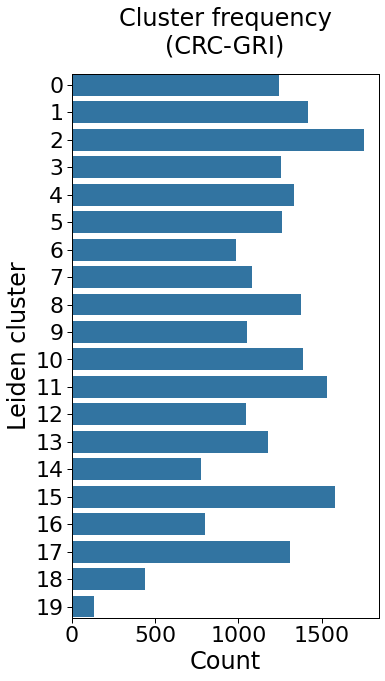

In [4]:
sns.set_context("paper", font_scale=2.5)
mpl.rcParams['pdf.fonttype']=42

# fig, ax = plt.subplots(figsize=(10.5,15))
fig, ax = plt.subplots(figsize=(5.5,10))

sns.countplot(all_df, y='leiden', color='tab:blue', ax=ax)
ax.set_xlabel('Count')
ax.set_ylabel('Leiden cluster')
ax.set_title('Cluster frequency\n(CRC-GRI)', pad=20)
ax.margins(y=0)


### Patient specificity

In [5]:
max_patient = list()

for cluster in adata_train.obs['leiden'].dropna().unique():
    cluster_subset = adata_train.obs[adata_train.obs['leiden'] == cluster]
    cluster_size = len(cluster_subset)
    patients, counts = np.unique(cluster_subset['samples'].values, return_counts=True)
    counts_props = counts / cluster_size
    max_idx = np.argmax(counts_props)
    max_val = counts_props[max_idx]
    max_patient.append((int(cluster), max_val * 100))


In [6]:
max_patient_df = pd.DataFrame(max_patient, columns=['Cluster', 'max_perc'])
max_patient_df = max_patient_df.sort_values(by='Cluster')
max_patient_df

,Cluster,max_perc
8,0,2.402402
2,1,1.958042
7,2,1.890990
4,3,4.204204
0,4,2.155172
16,5,4.041916
9,6,1.941748
3,7,3.535354
6,8,3.102962
5,9,5.017301


Text(0.5, 1.0, 'Patient specificity\n(CRC-GRI)')

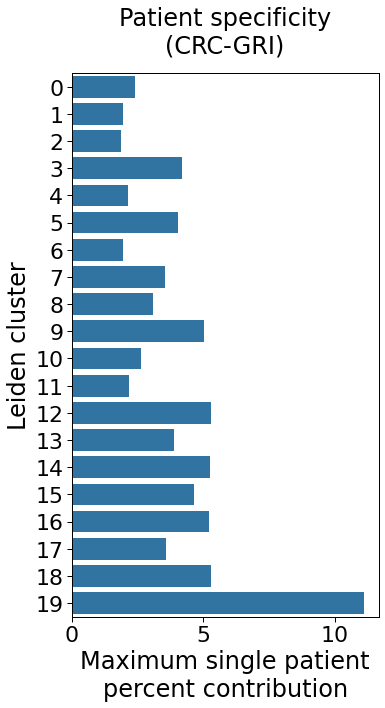

In [7]:
fig, ax = plt.subplots(figsize=(5.5,10))

sns.barplot(max_patient_df, x = 'max_perc', y = 'Cluster', orient='h', ax=ax)
ax.set_xlabel('Maximum single patient\npercent contribution')
ax.set_ylabel('Leiden cluster')
ax.set_title('Patient specificity\n(CRC-GRI)', pad=20)

### Slide specificity

In [8]:
adata_train.obs['slide'] = adata_train.obs['patch_path'].str.decode('utf-8').apply(lambda x: x.split(' ')[1])

In [9]:
max_slide = list()

for cluster in adata_train.obs['leiden'].dropna().unique():
    cluster_subset = adata_train.obs[adata_train.obs['leiden'] == cluster]
    cluster_size = len(cluster_subset)
    patients, counts = np.unique(cluster_subset['slide'].values, return_counts=True)
    counts_props = counts / cluster_size
    max_idx = np.argmax(counts_props)
    max_val = counts_props[max_idx]
    max_slide.append((int(cluster), max_val * 100))


In [10]:
max_slide_df = pd.DataFrame(max_slide, columns=['Cluster', 'max_perc'])
max_slide_df = max_slide_df.sort_values(by='Cluster')
max_slide_df

,Cluster,max_perc
8,0,15.465465
2,1,20.139860
7,2,13.904338
4,3,21.021021
0,4,15.086207
16,5,33.083832
9,6,23.495146
3,7,59.427609
6,8,20.733427
5,9,14.878893


Text(0.5, 1.0, 'Slide specificity\n(CRC-GRI)')

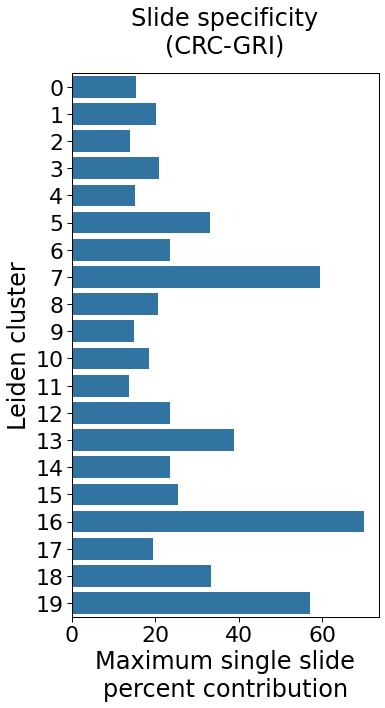

In [11]:
fig, ax = plt.subplots(figsize=(5.5,10))

sns.barplot(max_slide_df, x = 'max_perc', y = 'Cluster', orient='h', ax=ax)
ax.set_xlabel('Maximum single slide\npercent contribution')
ax.set_ylabel('Leiden cluster')
ax.set_title('Slide specificity\n(CRC-GRI)', pad=20)